In [1]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
# =========================
# Load dataset splits
# =========================
DATA_PATH = "../../Datasets/Norway InfiniumPurify Dataset Splits"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train = np.ravel(Y_train)
y_test  = np.ravel(Y_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((218, 21101), (54, 21101), (218,), (54,))


Calculating SHAP values...
SHAP values shape: (54, 500, 5)
Selected features: 500

=== Overall Top 10 Features ===
     Feature  MeanAbsSHAP_MaxAcrossSubtypes
431     CFL2                       0.014542
89   TMPRSS5                       0.011532
81      SOS1                       0.011144
168     CHD1                       0.010734
86     TTC36                       0.009126
347  MIR520D                       0.008930
197   PCNXL3                       0.008626
472    REP15                       0.008075
7      KLHL2                       0.007928
15    TMEM26                       0.007895


C:\Users\Roooiz\AppData\Local\Temp\ipykernel_21652\2427387025.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


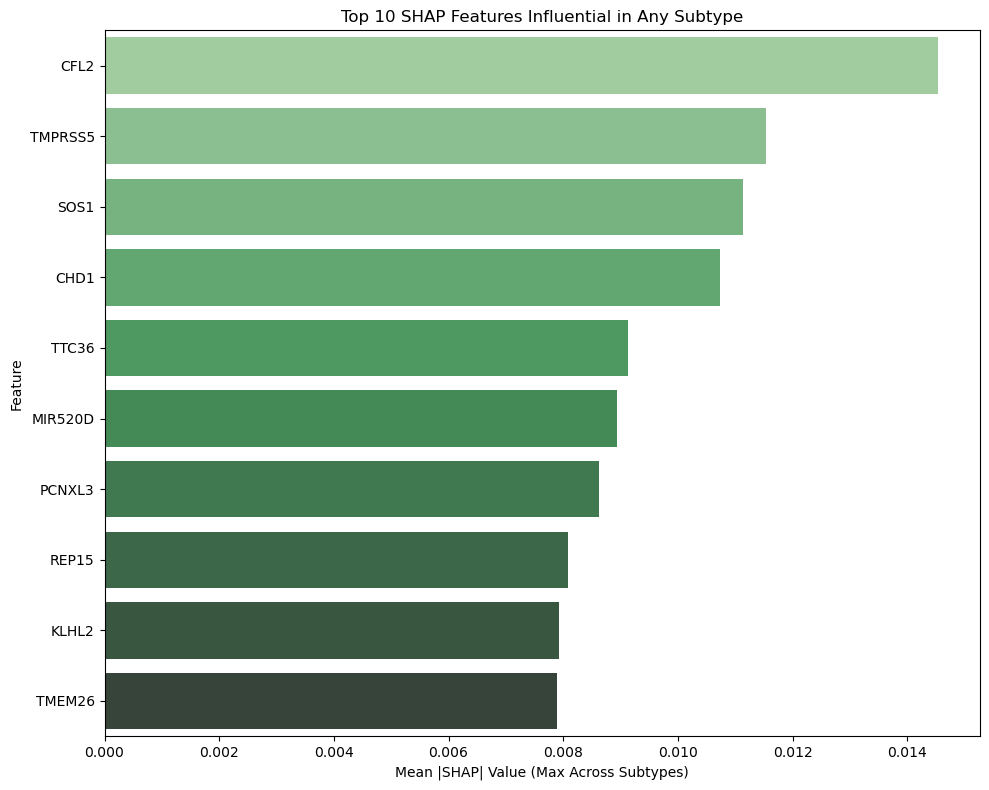

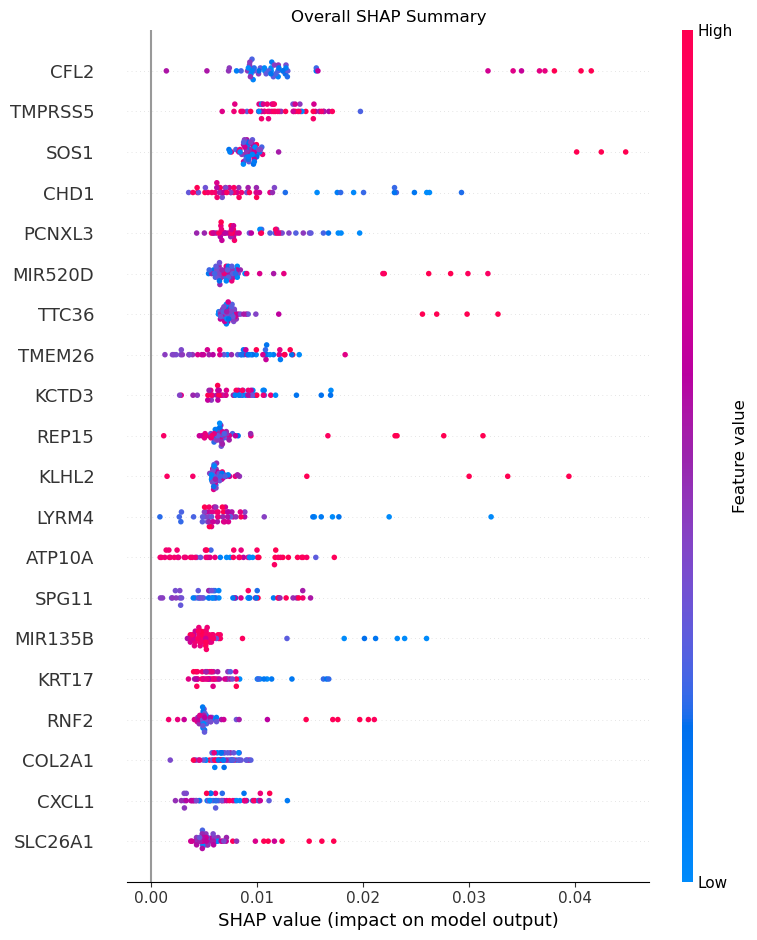


Subtype 1: Basal
     Feature  MeanAbsSHAP
81      SOS1     0.011144
86     TTC36     0.009126
347  MIR520D     0.008930
472    REP15     0.008075
7      KLHL2     0.007928
258  MIR135B     0.006908
163     RNF2     0.006689
243  SLC26A1     0.006570
471  SLC46A2     0.006493
11   SLC16A1     0.006226


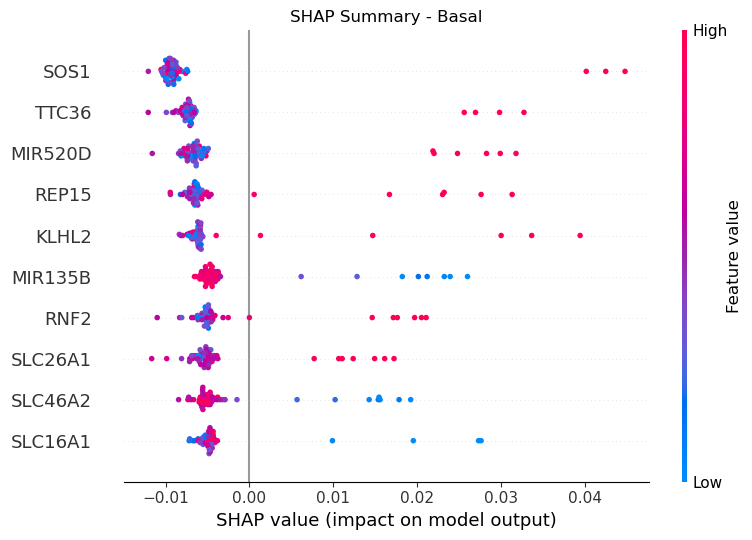

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_21652\2427387025.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


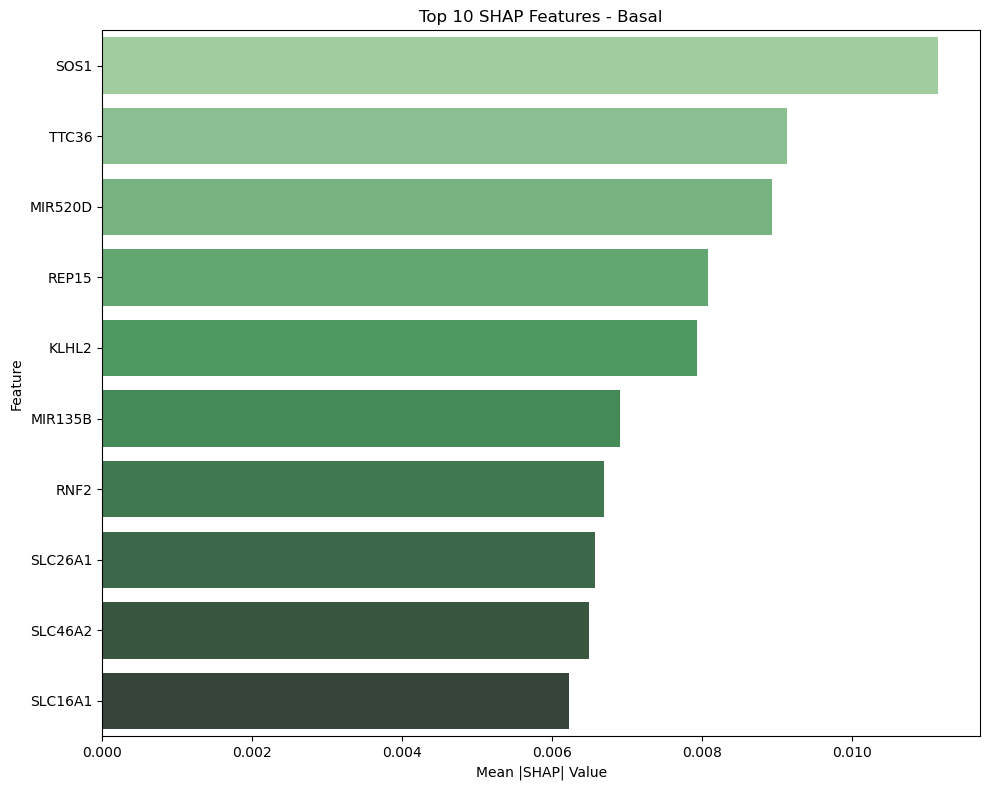


Subtype 2: Her2
     Feature  MeanAbsSHAP
431     CFL2     0.014542
15    TMEM26     0.007895
197   PCNXL3     0.007080
196    CXCL1     0.006550
408    SPG11     0.006154
208    KCTD3     0.006016
168     CHD1     0.005999
24    PMEPA1     0.005227
394  TOMM20L     0.005139
89   TMPRSS5     0.004764


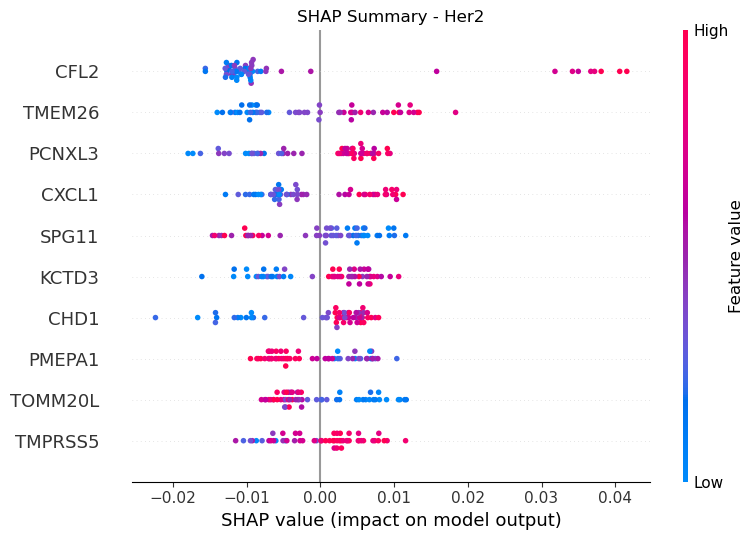

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_21652\2427387025.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


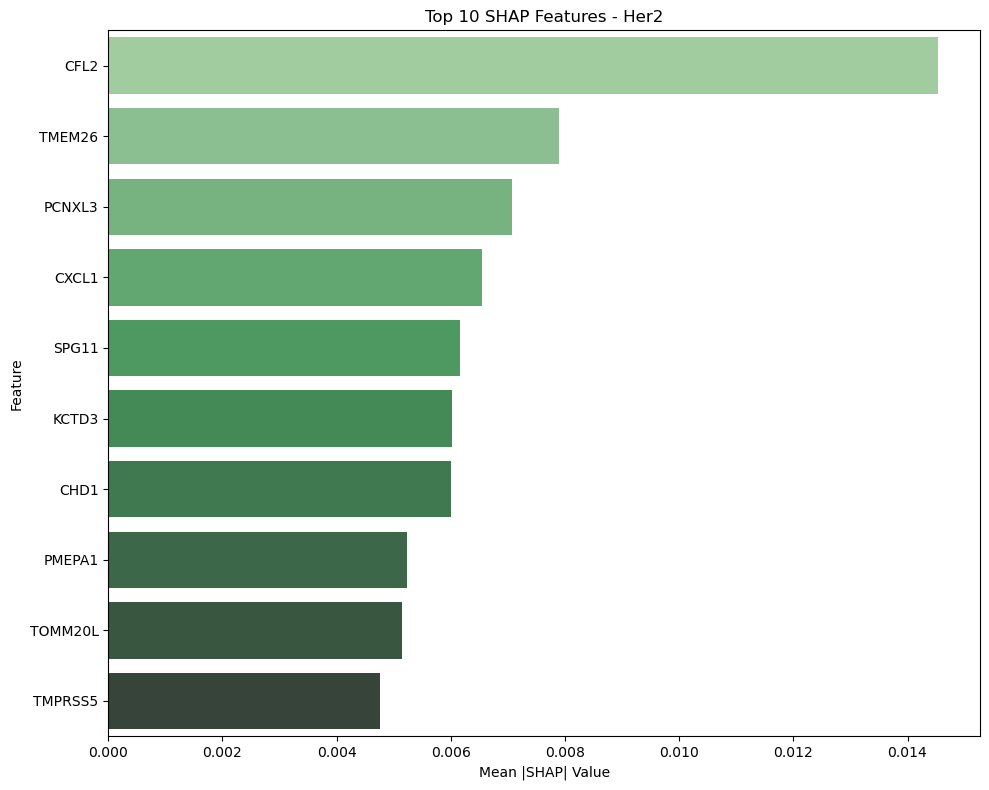


Subtype 3: LumA
     Feature  MeanAbsSHAP
37    ATP10A     0.007342
408    SPG11     0.006150
197   PCNXL3     0.006018
431     CFL2     0.005934
1    MIR1178     0.005735
92    COL2A1     0.005668
426    NHEG1     0.004946
2        CIT     0.004779
208    KCTD3     0.004526
209   CLDN25     0.004468


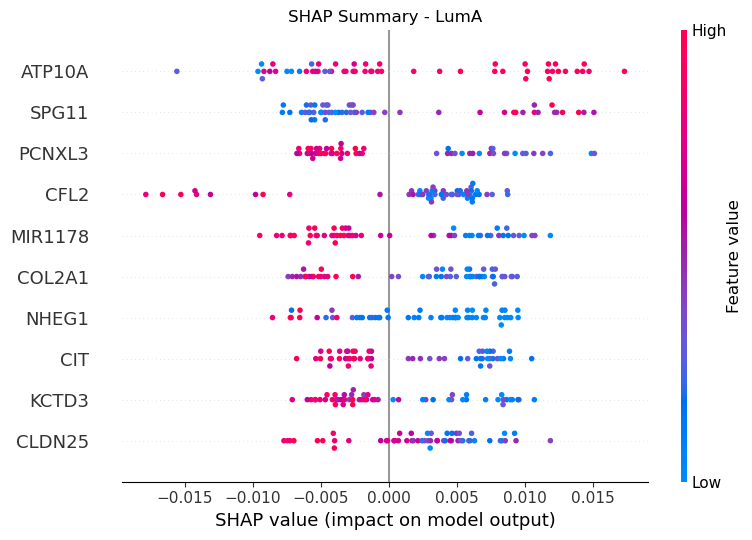

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_21652\2427387025.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


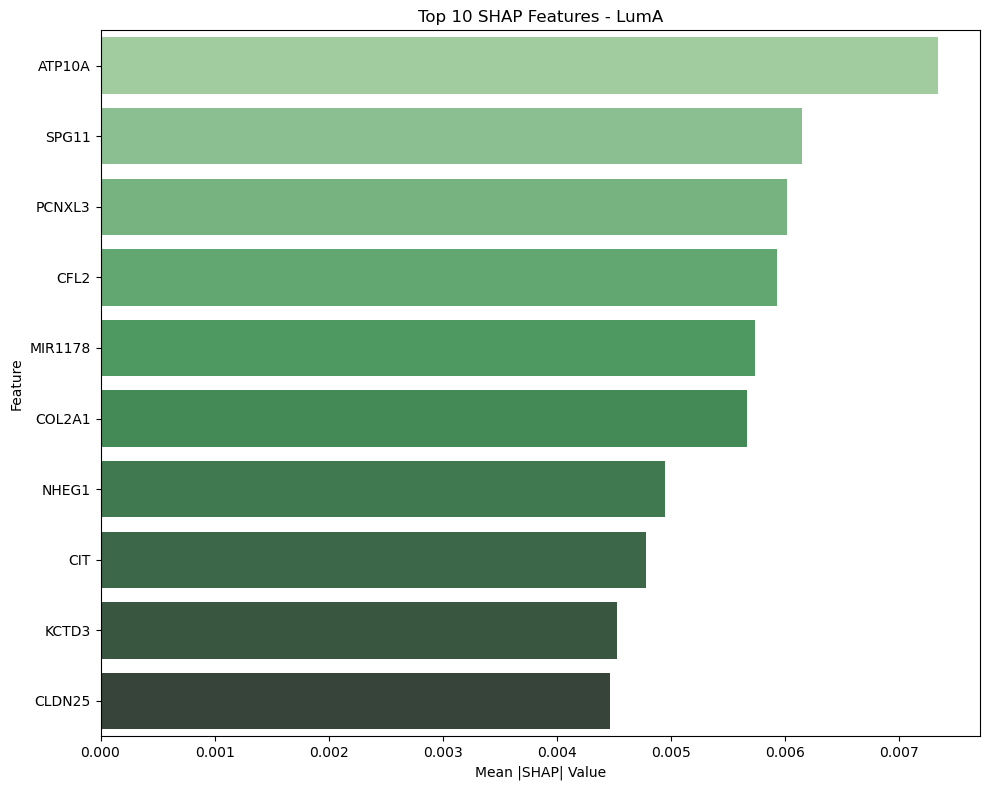


Subtype 4: LumB
     Feature  MeanAbsSHAP
89   TMPRSS5     0.011532
168     CHD1     0.010734
208    KCTD3     0.007738
15    TMEM26     0.006874
197   PCNXL3     0.005828
454    POTEG     0.004681
249    SMYD4     0.004277
347  MIR520D     0.004205
37    ATP10A     0.004170
431     CFL2     0.004131


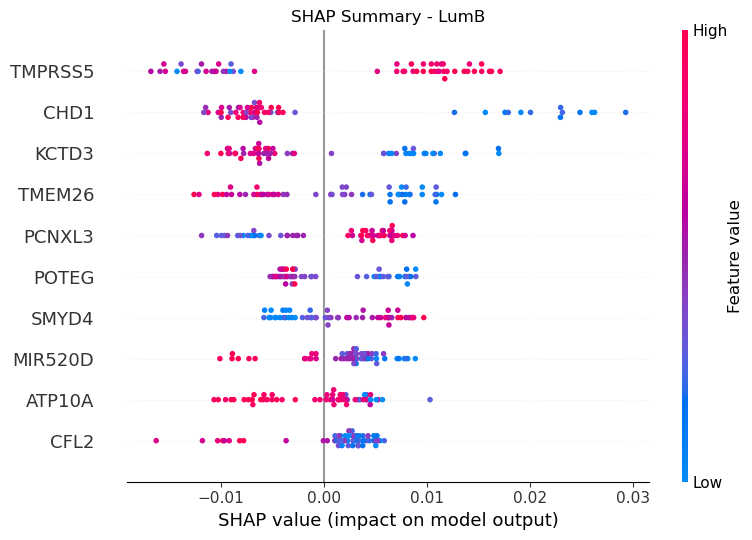

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_21652\2427387025.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


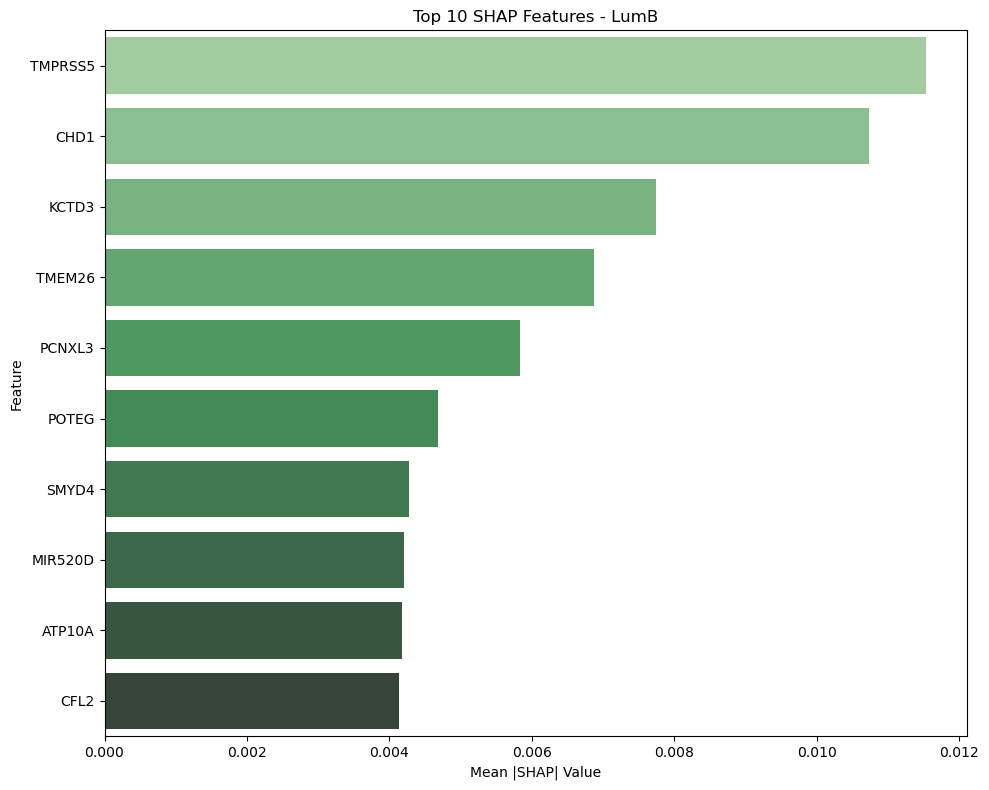


Subtype 5: Normal
      Feature  MeanAbsSHAP
89    TMPRSS5     0.009335
197    PCNXL3     0.008626
373     LYRM4     0.007863
96      KRT17     0.006472
92     COL2A1     0.005808
347   MIR520D     0.005274
180    ZC3H7A     0.004827
209    CLDN25     0.004820
17   C21orf70     0.004754
84    MIR1246     0.004612


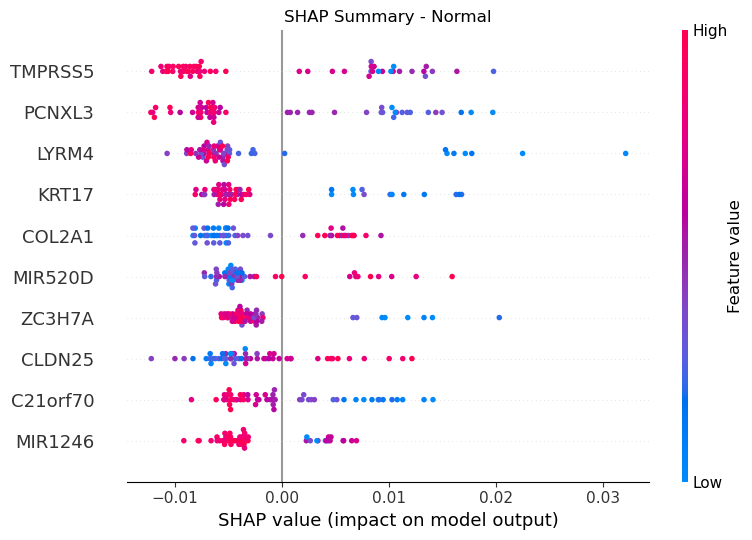

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_21652\2427387025.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


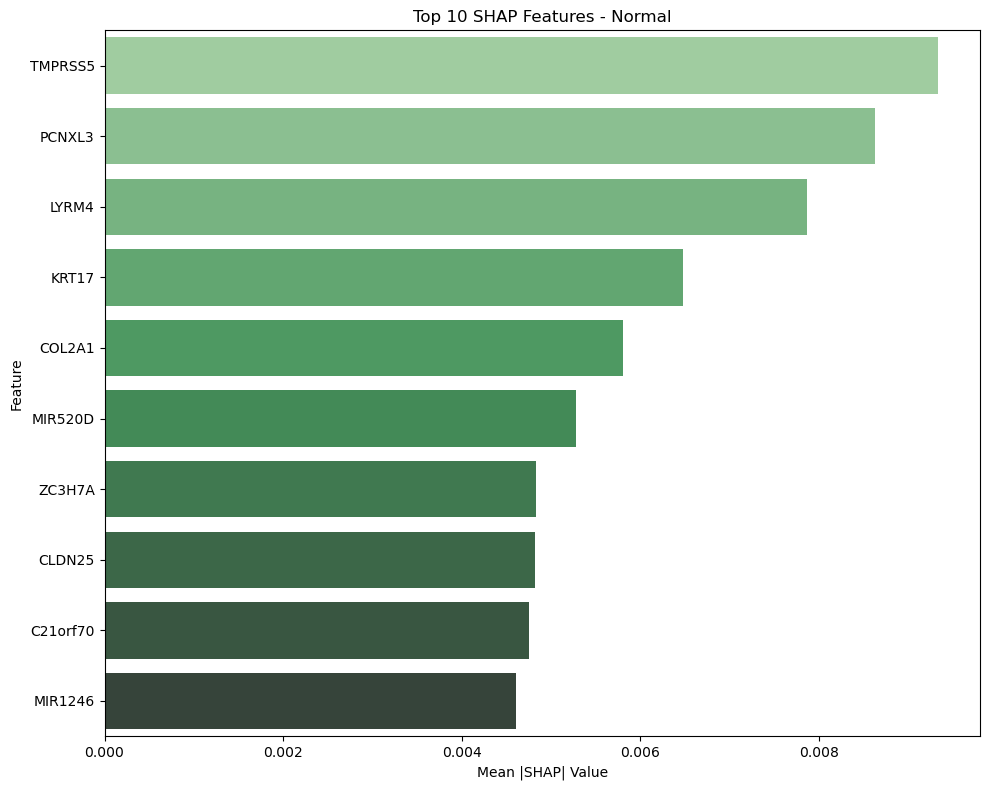


SHAP analysis complete — both overall and per-subtype results generated.


In [3]:
# --- Choose your model ---
best_model_rfe = joblib.load("PKL/RF_Norway_IP_SMOTE_RFE.pkl")
pipeline_model = best_model_rfe  # or best_model_no_rfe

# --- Extract components ---
rfe = pipeline_model.named_steps['rfe']
rf_model = pipeline_model.named_steps['rf']
scaler = pipeline_model.named_steps['scaler']

# --- Prepare data ---
selected_mask = rfe.support_  # which features RFE kept
selected_features = np.array(X_test.columns)[selected_mask]

# Scale test set
X_test_scaled = scaler.transform(X_test)
X_test_selected = X_test_scaled[:, selected_mask]

# --- Create SHAP explainer ---
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_selected)

# Handle multi-class output
if isinstance(shap_values, list):  # one array per class
    shap_values = np.stack(shap_values, axis=2)  # shape: (samples, features, classes)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Selected features: {len(selected_features)}")

# ====================================================
# 1. OVERALL (across all classes)
# ====================================================
mean_abs_shap_anywhere = np.abs(shap_values).mean(axis=0).max(axis=1)

shap_importances_overall = pd.DataFrame({
    "Feature": selected_features,
    "MeanAbsSHAP_MaxAcrossSubtypes": mean_abs_shap_anywhere
}).sort_values(by="MeanAbsSHAP_MaxAcrossSubtypes", ascending=False)

print("\n=== Overall Top 10 Features ===")
print(shap_importances_overall.head(10))

# Bar plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=shap_importances_overall.head(10),
    x="MeanAbsSHAP_MaxAcrossSubtypes",
    y="Feature",
    palette="Greens_d"
)
plt.title("Top 10 SHAP Features Influential in Any Subtype")
plt.xlabel("Mean |SHAP| Value (Max Across Subtypes)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Overall SHAP summary
shap_values_overall = np.abs(shap_values).max(axis=2)  # max per sample across classes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_overall, X_test_selected,
    feature_names=selected_features,
    max_display=20, show=False
)
plt.title("Overall SHAP Summary")
plt.tight_layout()
plt.show()

# ====================================================
# 2. PER-CLASS (each subtype separately)
# ====================================================
class_names = rf_model.classes_
for class_idx, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"Subtype {class_idx + 1}: {class_name}")
    
    shap_values_class = shap_values[:, :, class_idx]
    class_mean_abs_shap = np.abs(shap_values_class).mean(axis=0)
    
    shap_importances_class = pd.DataFrame({
        "Feature": selected_features,
        "MeanAbsSHAP": class_mean_abs_shap
    }).sort_values(by="MeanAbsSHAP", ascending=False)
    
    print(shap_importances_class.head(10))
    
    # SHAP summary plot per class
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_class, X_test_selected,
        feature_names=selected_features,
        max_display=10, show=False
    )
    plt.title(f"SHAP Summary - {class_name}")
    plt.tight_layout()
    plt.show()
    
    # Bar plot top 10 per class
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=shap_importances_class.head(10),
        x="MeanAbsSHAP",
        y="Feature",
        palette="Greens_d"
    )
    plt.title(f"Top 10 SHAP Features - {class_name}")
    plt.xlabel("Mean |SHAP| Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

print("\nSHAP analysis complete — both overall and per-subtype results generated.")